## Vehicle Detection [Bus and Truck Detection]
### Overview

This notebook covers using RCNN to detect bus or truck in an image.

In [28]:
import os
import pickle as pkl 
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn

import cv2
import selectivesearch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision import models
from torchsummary import summary

### DataPaths

In [29]:
image_paths =   r'D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\images'
csv_path    =   r"D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\df.csv"

### Hyperparameters

In [30]:
BATCH_SIZE      =   16
NUM_EPOCHS      =   10
LEARNING_RATE   =   0.0001
THRESHOLD_IOU   =   0.5
DEVICE          =   torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cuda')

### Open Image Dataset Loading

In [31]:
class OpenImageDataset(Dataset):
    def __init__(self, image_paths, csv_path):
        super().__init__()
        self.image_paths    = image_paths
        self.csv_paths      = csv_path
        self.df             = pd.read_csv(csv_path)
        self.unique_images  = self.df['ImageID'].unique()
        
    def __len__(self):
        return len(self.unique_images)
    
    def __getitem__(self,index):
        if isinstance(index, slice):
            indices = range(*index.indices(len(self.unique_images)))
            return [ self._load_item(i) for i in indices]
        else:
            return self._load_item(index)
    
    def _load_item(self, index):
        
        image_id        = self.unique_images[index]
        image_full_path = os.path.join(self.image_paths, image_id + ".jpg")
        image           = cv2.imread(image_full_path,cv2.IMREAD_COLOR)
        image           = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        h, w, _         = image.shape
        
        df      = self.df.loc[self.df['ImageID'] == image_id]
        
        bboxes  = df[['XMin', 'YMin', 'XMax', 'YMax']].values
        bboxes  = (bboxes * np.array([w,h,w,h])).astype(np.uint16)
        
        classes = df['LabelName'].values 
        
        return image, bboxes, classes, image_full_path
        

In [32]:
datasets = OpenImageDataset(image_paths, csv_path)

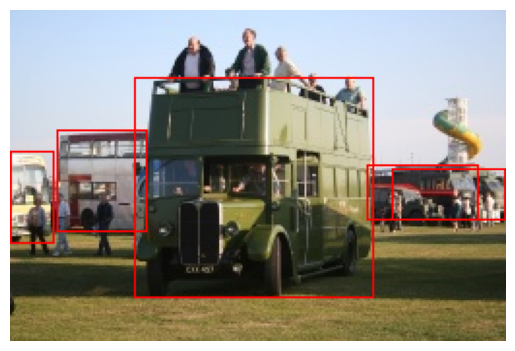

In [33]:
img, bbx,_,_ = datasets[14]

for bb in bbx:
    x_min, y_min, x_max, y_max = bb
    cv2.rectangle( img, (x_min, y_min), (x_max, y_max), color = (255,0,0), thickness= 1)

plt.imshow(img)
plt.axis(False)
plt.show()



### Extracting Candidates regions

In [34]:
def extract_candidates(img):
    _, regions = selectivesearch.selective_search(img,
                                                 scale=100,
                                                 min_size=50)
    candidates = []
    img_area   = np.prod(img.shape[:2]) 
    for region in regions:
        if region['rect'] in candidates:
            continue
        if region['size'] < 0.05*img_area:
            continue
        
        candidates.append(region['rect'])
    return candidates 

def extract_iou(bbox1, bbox2, epsilon=1e-5):
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])

    width = x2 - x1
    height = y2 - y1

    if width < 0 or height < 0:
        return 0
    
    intersection_area = width * height 
    area_1 = (bbox1[2] - bbox1[0]) * (bbox1[3] - bbox1[1])
    area_2 = (bbox2[2] - bbox2[0]) * (bbox2[3] - bbox2[1])

    union_area = area_1 + area_2 - intersection_area
    
    return intersection_area / (union_area + epsilon)

In [35]:
def extract_all(t):
    image, bboxes, classes, image_full_path = t
    H, W, _ = image.shape
    candidates = extract_candidates(image)
    candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

    clss, deltas, rois = [], [], []
    ious = np.array([[extract_iou(candidate, bbox) for bbox in bboxes] for candidate in candidates])
    
    for j, candidate in enumerate (candidates):
        cx, cy, cX, cY = candidate
        candidate_ious = ious[j]
        best_iou_at = np.argmax(candidate_ious)
        best_iou = candidate_ious[best_iou_at]
        best_bb = _x, _y, _X, _Y = bboxes[best_iou_at]

        if best_iou > THRESHOLD_IOU:
            clss.append(classes[best_iou_at])
        else:
            clss.append('background')

        delta = np.array([_x - cx, _y - cy, _X - cX, _Y - cY]) / np.array([W, H, W, H])
        deltas.append(delta)

        rois.append(candidate / np.array([W, H, W, H]))

    return image_full_path, bboxes, clss, deltas, rois, ious

In [36]:
# from multiprocessing import Pool
# FULL_PATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []

# with Pool(10) as p:
#     results = p.imap(extract_all, datasets)
#     for result in tqdm(results):
#         image_full_path, bboxes, clss, deltas, rois, ious = result
#         FULL_PATHS.append(image_full_path)
#         GTBBS.append(bboxes)
#         CLSS.append(clss)
#         DELTAS.append(deltas)
#         ROIS.append(rois)
#         IOUS.append(ious)

### Pickle Utils Function

In [37]:
import pickle
def save_pickle(var, path):
    with open(path, 'wb') as file:
        pickle.dump(var, file)

def load_pickle(path):
    with open(path, 'rb') as file:
        return pickle.load(file)

# save_pickle(FULL_PATHS, 'full_paths.pkl')
# save_pickle(GTBBS, 'gtbbs.pkl')
# save_pickle(CLSS, 'clss.pkl')
# save_pickle(DELTAS, 'deltas.pkl')
# save_pickle(ROIS, 'rois.pkl')
# save_pickle(IOUS, 'ious.pkl')



In [38]:
FULL_PATHS  = load_pickle('full_paths.pkl')
GTBBS       = load_pickle('gtbbs.pkl')  # Ground Truth Bounding box
CLSS        = load_pickle('clss.pkl')   # Classes of each GTBBS
DELTAS      = load_pickle('deltas.pkl')
ROIS        = load_pickle('rois.pkl')
IOUS        = load_pickle('ious.pkl')


### Key Terms 

1. **FULL_PATHS – Image File Locations**  
   - List containing absolute file paths of processed images  
   - Format: `List[str]` (e.g., `["/data/img1.jpg", "/data/img2.jpg"]`)

2. **GTBBS – Ground Truth Bounding Boxes**  
   - Real object locations in images  
   - Format: `List[List[(x_min, y_min, x_max, y_max)]]`  

3. **CLSS – Class Labels for Regions**  
   - Class assignments for each proposal  
   - "background" if IoU < threshold  
   - Format: `List[List["class_name"]]`  
   - Example: `[["dog", "background"], ["cat"]]`

4. **DELTAS – Bounding Box Regression Offsets**  
   - Adjustment values to match proposals to ground truth  
   - Format: `List[[Δx, Δy, Δwidth, Δheight]]`  
   - **Calculation**:  
     ```
     Δx = (gt_x1 - x1) / width
     Δy = (gt_y1 - y1) / height
     Δwidth = (gt_x2 - x2) / width
     Δheight = (gt_y2 - y2) / height
     ```

5. **ROIS – Regions of Interest**  
   - Normalized proposal coordinates (0-1 range)  
   - Format: `List[[x1_norm, y1_norm, x2_norm, y2_norm]]`  
   - **Calculation**:  
     ```
     x1_norm = x1 / image_width
     y1_norm = y1 / image_height
     x2_norm = x2 / image_width
     y2_norm = y2 / image_height
     ```

6. **IOUS – Intersection over Union Scores**  
   - Overlap quality between proposals and ground truth  
   - Format: `2D array[proposal_idx][gt_box_idx]`  
   - **Calculation**:  
     ```
     IoU = Area_of_Intersection / Area_of_Union
     ```
   - Used to assign CLSS and DELTAS when IoU > threshold (typically 0.5)

In [39]:
# FULL_PATHS might change,  so modify path accordingly 

FULL_PATHS = [
    i.replace(
        r'D:\Code\DeepLearning\phase2\Object detection\implementation\images',
        r'D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\images'
    )
    for i in FULL_PATHS
]

In [40]:
image           = cv2.imread(FULL_PATHS[102],cv2.IMREAD_COLOR)
image           = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

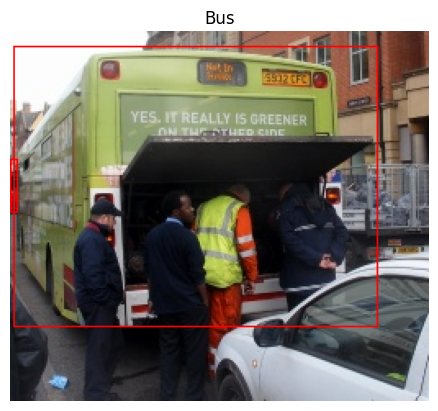

In [41]:
bbx     = GTBBS[102]
classes = CLSS[102]
classes = np.unique(np.array(classes))[0]
for bb in bbx:
    x_min, y_min, x_max, y_max = bb
    cv2.rectangle( image, (x_min, y_min), (x_max, y_max), color = (255,0,0), thickness= 1)
plt.imshow(image)
plt.axis(False)
plt.title(classes)
plt.show()

In [42]:
len(FULL_PATHS), len(GTBBS), len(CLSS), len(DELTAS), len(ROIS), len(IOUS)

(15225, 15225, 15225, 15225, 15225, 15225)

In [43]:
unique_labels   = np.unique(np.array([c for clss in CLSS for c in clss])) # 2d data lai 1d ma lerayera unique label nikaleko

target2label    = {i:label for i , label in enumerate(unique_labels)}
label2target    = {label:i for i , label in enumerate(unique_labels)}

label2target


{np.str_('Bus'): 0, np.str_('Truck'): 1, np.str_('background'): 2}

### Datasets for R-CNN

In [44]:
def preprocess(img):
    crop_img    = torch.tensor(img).permute(2,0,1)
    normalize   = transforms.Normalize(
                        mean = [0.485, 0.456, 0.406],
                        std  = [0.229, 0.224, 0.225]
                                      )
    crop_img    = normalize(crop_img)
    return crop_img.float()

In [45]:
class RCNNDataset(Dataset):
    def __init__(self, fpaths, rois, gtbbs, labels, deltas, ious):
        super().__init__()
        self.fpaths     = fpaths
        self.rois       = rois
        self.labels     = labels
        self.gtbbs      = gtbbs
        self.deltas     = deltas
        self.ious       = ious 
        
        self.label2target = {'background':0, 'bus':1, 'truck':2}
    
    def __len__(self):
        return len(self.fpaths)
    
    def __getitem__(self, index):
        
        fpath = self.fpaths[index]
        image = cv2.imread(fpath, cv2.IMREAD_COLOR)[..., ::-1]  # Convert BGR to RGB
        H, W, _ = image.shape

        gtbbs = self.gtbbs[index]

        rois = self.rois[index]
        bbs = (rois * np.array([W, H, W, H])).astype(np.uint8)
     
        crops = [image[y:Y, x:X] for x, y, X, Y in bbs]
        labels = self.labels[index]
        deltas = self.deltas[index]
        

        return image, gtbbs, bbs, crops, labels, deltas, fpath

    def collate_fn(self, batch):
        inputs, output_labels, output_deltas = [], [], []
        for i in range(len(batch)):
            image, gtbbs, bbs, crops, labels, deltas, fpath = batch[i]
            
            # Resize valid crops and preprocess them
            crops = [cv2.resize(crop,(224, 224)) for crop in crops ]
            crops = [preprocess(crop/255.0)[None] for crop in crops]
            
            inputs.extend(crops)
            output_labels.extend([label2target[label] for label in labels])
            output_deltas.extend(deltas)

        inputs = torch.cat(inputs).to(DEVICE)
        output_labels = torch.tensor(output_labels).long().to(DEVICE)
        output_deltas = torch.tensor(np.array(output_deltas)).float().to(DEVICE)

        return inputs, output_labels, output_deltas
    
#Each image may contain a different number of object crops (regions of interest).
#The default PyTorch DataLoader cannot stack these uneven lists, 
# so a custom function like collate_fn is needed.

In [46]:
n_train = int(len(FULL_PATHS) * 0.8)

train_dataset = RCNNDataset(FULL_PATHS[:n_train], ROIS[:n_train], GTBBS[:n_train], CLSS[:n_train], DELTAS[:n_train], IOUS[:n_train])
test_dataset = RCNNDataset(FULL_PATHS[n_train:], ROIS[n_train:], GTBBS[n_train:], CLSS[n_train:], DELTAS[n_train:], IOUS[n_train:])

In [47]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=train_dataset.collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=test_dataset.collate_fn)

### Model Architecture

In [48]:
backbone = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)

backbone.fc = nn.Sequential()

for param in backbone.parameters():
    param.requires_grad = False 

backbone.to(device = DEVICE)
summary(backbone.to(DEVICE), (3,224,224)) 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [49]:
class RCNN(nn.Module):
    def __init__(self, backbone,n_classes):
        super().__init__()
        self.backbone = backbone
        self.n_classes = n_classes
        
        self.classification_head = nn.Linear(2048, n_classes)

        self.bbox_regression_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 4),
            nn.Tanh()
        )
        
    def forward(self, inputs):
        feat = self.backbone(inputs)

        cls_score = self.classification_head(feat)
        
        deltas = self.bbox_regression_head(feat)
        
        return cls_score, deltas

            
#inputs, _ , _ = next(iter(train_dataloader))
model = RCNN(backbone=backbone, n_classes=len(unique_labels)).to(device=DEVICE)
model = torch.nn.DataParallel(model).to(DEVICE)


    

In [50]:
from torch import optim
from torchvision import models
criterion_cls = nn.CrossEntropyLoss()
criterion_bbox = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
n_epochs=5


In [51]:
def train_batch(imgs,kps,model,optimizer,criterion):
    model.train()
    optimizer.zero_grad()
    pred=model(imgs)
    loss=criterion(pred,kps)
    
    loss.backward()
    optimizer.step()
    return loss

@torch.no_grad()
def model_test(img,kps,model,criterion):
    model.eval()
    pred=model(img)
    loss=criterion(pred,kps)

    return loss

In [ ]:
train_loss = []
test_loss=[]

for epoch in range(1, n_epochs + 1):
    
    epoch_loss = 0
    epoch_tloss=0
    
    for inputs, labels, deltas in tqdm(train_dataloader, desc=f'Training Epoch {epoch}/{n_epochs}'):
        model.train()
        cls_preds, bbox_preds = model(inputs)
    
        loss_cls = criterion_cls(cls_preds, labels)
        loss_bbox = criterion_bbox(bbox_preds, deltas)
        loss = loss_cls + loss_bbox
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_tloss += loss.item()
    
    epoch_tloss /= len(train_dataloader)
    train_loss.append(epoch_tloss)
    
    for inputs, labels, deltas in tqdm(test_dataloader, desc=f'Training Epoch {epoch}/{n_epochs}'):
        model.eval()
        cls_preds, bbox_preds = model(inputs)
    
        loss_cls = criterion_cls(cls_preds, labels)
        loss_bbox = criterion_bbox(bbox_preds, deltas)
        loss = loss_cls + loss_bbox
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(test_dataloader)
    train_loss.append(epoch_loss)
    
    print(f'Epoch {epoch}/{n_epochs}: Train Loss: {epoch_tloss:.4f} Test Loss: {epoch_loss:4f}')
torch.save(model.state_dict(),'new_model.pth')

Training Epoch 1/5:  41%|████      | 314/762 [2:17:33<3:11:56, 25.71s/it]